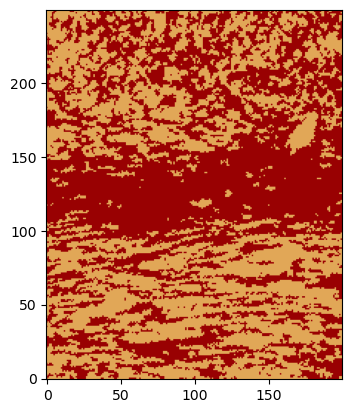

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

import bitis as bt


tex_cmap = mcolors.LinearSegmentedColormap.from_list(
    'fibrosis', [(0, 'white'),
                 (0.5, '#e2a858'),
                 (1, '#990102')])

texture = np.load("/Users/arstanbek/Projects/fibrosis/BiTis/bitis/datasets/epi_endo_sample.npy")
texture = texture[:, :200]

plt.figure()
plt.imshow(texture, origin='lower', vmin=0, vmax=2, cmap=tex_cmap)
plt.show()

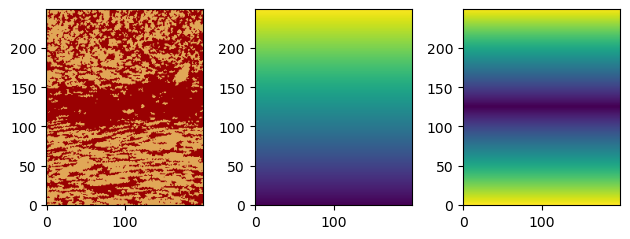

In [57]:
distance_map = np.zeros_like(texture, dtype=float)

rows, cols = texture.shape  # example shape

y = np.arange(rows)
Y = np.tile(y.reshape(rows, 1), (1, cols)).astype(float)

Y /= Y.max()

YY = 0.5 - np.where(Y > 0.5, np.abs(Y - 1), Y)
YY /= YY.max()

fig, axs = plt.subplots(ncols=3)
axs[0].imshow(texture, origin='lower', vmin=0, vmax=2, cmap=tex_cmap)
axs[1].imshow(Y, origin='lower')
axs[2].imshow(YY, origin='lower')
plt.tight_layout()
plt.show()

100%|██████████| 50000/50000 [00:24<00:00, 2021.47it/s]


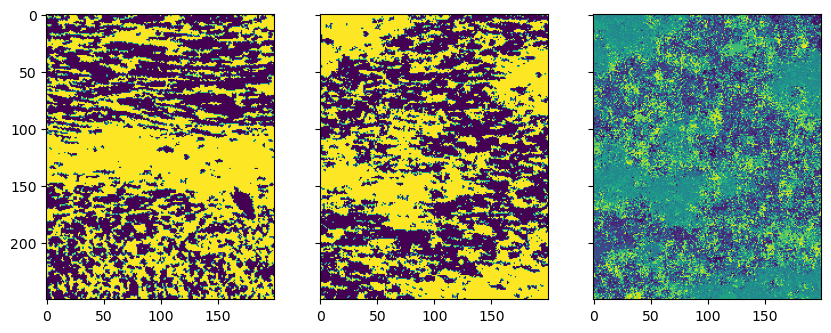

In [65]:
training_tex = texture.copy()

simulation_tex = np.zeros(training_tex.shape)
simulation = bt.AdaptiveSampling(simulation_tex,
                                 training_tex,
                                 max_known_pixels=30,
                                 min_known_pixels=5,
                                 max_template_size=100,
                                 min_template_size=5,
                                 n_candidates=1)

adaptive_tex = simulation.run().copy()

fig, ax = plt.subplots(1, 3, figsize=(10, 5), sharex=True, sharey=True)
ax[0].imshow(training_tex)
ax[1].imshow(adaptive_tex)
ax[2].imshow(simulation._index_map)
plt.show()

100%|██████████| 50000/50000 [00:27<00:00, 1835.72it/s]


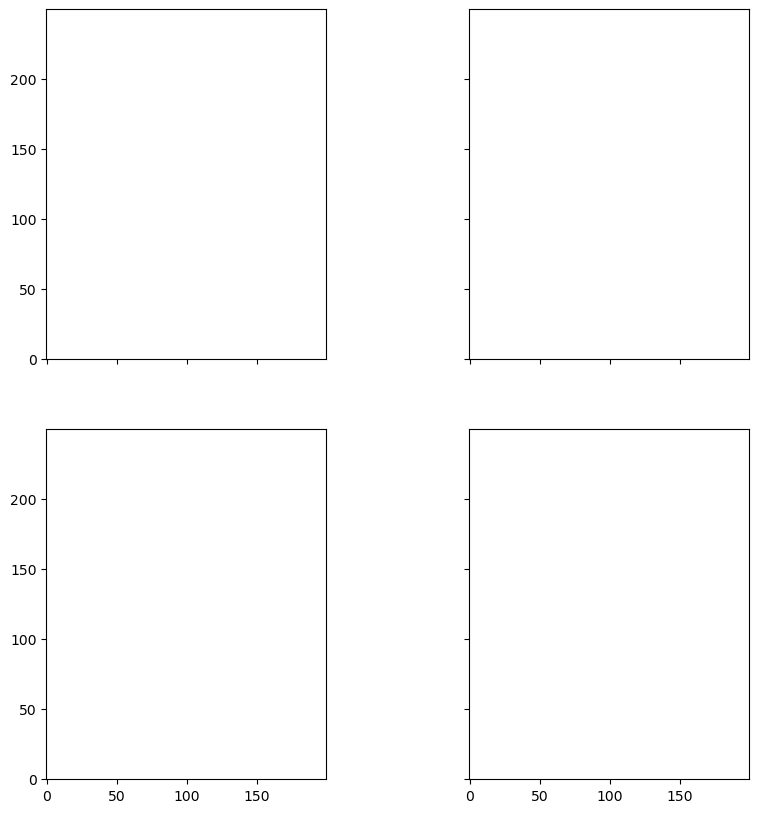

In [ ]:
training_image = texture.copy()
joint_training_image = Y

joint_sim_imgs = [Y, YY]
sim_imgs = []

max_known_pixels = 30
max_template_size = 40
min_template_size = 3
num_of_candidates = 1
min_known_pixels = 1

for joint_simulated_image in joint_sim_imgs:
    simulation_tex = np.zeros_like(joint_simulated_image)
    multi_var_simulation = bt.Simulation()
    multi_var_simulation.path_builder = bt.MultivariateSimulationPathBuilder(simulation_tex)
    multi_var_simulation.template_builder = bt.AdaptiveTemplateBuilder(simulation_tex,
                                                            max_known_pixels,
                                                            max_template_size,
                                                            min_template_size)
    multi_var_simulation.template_matching = bt.MultivariateVariableMatching(training_image,
                                                                joint_training_image,
                                                                joint_simulated_image,
                                                                num_of_candidates,
                                                                min_known_pixels)

    simulated_tex = multi_var_simulation.run()
    sim_imgs.append(simulated_tex.copy())

%matplotlib inline

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 10),
                       sharex=True, sharey=True)
ax[0, 0].imshow(training_image, origin="lower", vmin=0, vmax=2, cmap=tex_cmap)
ax[0, 1].imshow(simulated_tex, origin="lower", vmin=0, vmax=2, cmap=tex_cmap)
ax[1, 0].imshow(joint_training_image, origin="lower", vmin=0, vmax=1, cmap=tex_cmap)
ax[1, 1].imshow(joint_simulated_image, origin="lower", vmin=0, vmax=1, cmap=tex_cmap)
plt.show()

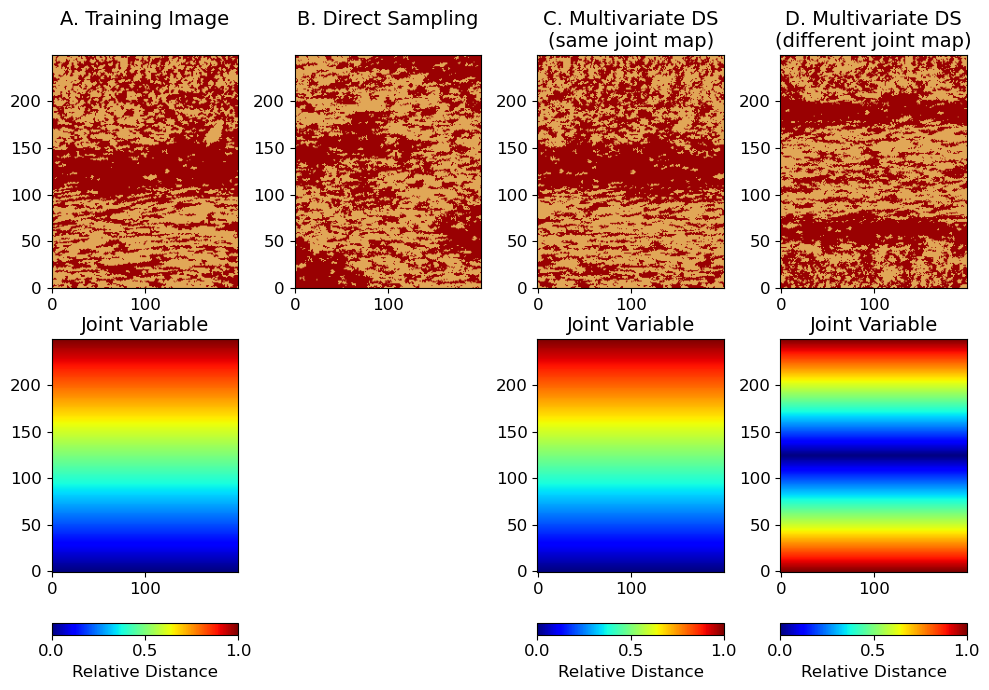

In [90]:
fig, axs = plt.subplots(ncols=4, nrows=3, figsize=(10, 7),
                        height_ratios=[1, 1, 0.05])
axs[0, 0].imshow(training_image, origin="lower", vmin=0, vmax=2, cmap=tex_cmap)
axs[1, 0].imshow(joint_sim_imgs[0], origin="lower", vmin=0, vmax=1, cmap='jet')

axs[0, 1].imshow(adaptive_tex, origin="lower", vmin=0, vmax=2, cmap=tex_cmap)
axs[1, 1].axis('off')
axs[2, 1].axis('off')

for i in range(2):
    axs[0, i+2].imshow(sim_imgs[i], origin="lower", vmin=0, vmax=2, cmap=tex_cmap)
    axs[1, i+2].imshow(joint_sim_imgs[i], origin="lower", vmin=0, vmax=1, cmap="jet")

for i in [0, 2, 3]:
    cbar = plt.colorbar(axs[1, i].images[0], cax=axs[2, i],
                        orientation='horizontal')
    cbar.set_label('Relative Distance', fontsize=12)

    for j in [0, 1]:
        axs[j, i].sharex(axs[0, 0])
        axs[j, i].sharey(axs[0, 0])


axs[0, 0].set_title('A. Training Image\n', fontsize=14)
axs[0, 1].set_title('B. Direct Sampling\n', fontsize=14)
axs[0, 2].set_title('C. Multivariate DS\n(same joint map)', fontsize=14)
axs[0, 3].set_title('D. Multivariate DS\n(different joint map)', fontsize=14)

axs[1, 0].set_title('Joint Variable', fontsize=14)
axs[1, 2].set_title('Joint Variable', fontsize=14)
axs[1, 3].set_title('Joint Variable', fontsize=14)


for ax in axs.flat:
    ax.set_anchor('NW')
    ax.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()

In [91]:
fig.savefig("figure7.png", dpi=300, bbox_inches='tight')